El sistema astronómico de magnitudes y colores
===

Autores
---
J.P. Calderón & R. Gamen

Resumen
---
Los filtros astronómicos permiten registrar parte del espectro
electromagnético de las estrellas en determinados rangos de
longitud de onda. Combinando las magnitudes en distintos filtros
se definen índices de color que nos ayudan a clasificar las
estrellas y estudiar sus características. El objetivo de esta
práctica es familiarizar al estudiante con los sistemas de
filtros más modernos y utilizarlos para cálculos sencillos.

Referencias
---
* [Práctica 02 (overleaf)](https://www.overleaf.com/read/qxwzwbnpbdnr)

---
      
Ejercicios
---
Objetivos:
* Calcular la longitud de onda efectiva y equivalente, teniendo en cuenta la sensibilidad de un determinado filtro y el flujo emitido por una determinada fuente.
* Graficar la sensibilidad de un sistema de filtros.
* Calcular los colores instrumentales a partir de una fuente de energía.
* Convolucionar un espectro estelar con la sensibilidad de un filtro y obtener la magnitud integrada.

**1.** Graficar las sensibilidades de los filtros. Tanto desde un archivo descargado, como desde un dado _url_.

In [1]:
import pandas as pd
data = pd.read_csv ( '../data/UBVRI.dat', names = [ 'filtro','long','sen','sen_nor' ], # TUBE QUE CAMBIAR LA RUTA PORQUE EL ARCHIVO UBRI.DAT NO ESTABA EN NOTEBOOKS
                    sep = " ", comment = '#', header = None )
data # Se accede a cada columna mediante: data[0], data[1], ...

,filtro,long,sen,sen_nor
0,B,3600,0.00,0.00
1,B,3650,0.00,0.00
2,B,3700,0.02,0.02
3,B,3750,0.05,0.05
4,B,3800,0.11,0.11
...,...,...,...,...
304,V,7150,0.01,0.01
305,V,7200,0.01,0.01
306,V,7250,0.01,0.01
307,V,7300,0.01,0.01


In [2]:
V_data = pd.read_csv('../data/V.dat', sep='\s+', comment='#', names=['Sp', 'M_V', 'B_V', 'U_B', 'V_R', 'R_I', 'Teff', 'BC'])
V_data

distribucion_K5V = pd.read_csv('../data/distribucion_espectral_K5V.dat', sep='\s+', comment='#', names=['wavelength_nm', 'intensity'])
distribucion_K5V

,wavelength_nm,intensity
0,120,0.0
1,125,0.0
2,130,0.0
3,135,0.0
4,140,0.0
...,...,...
183,1035,80.5
184,1040,81.2
185,1045,80.0
186,1050,78.5


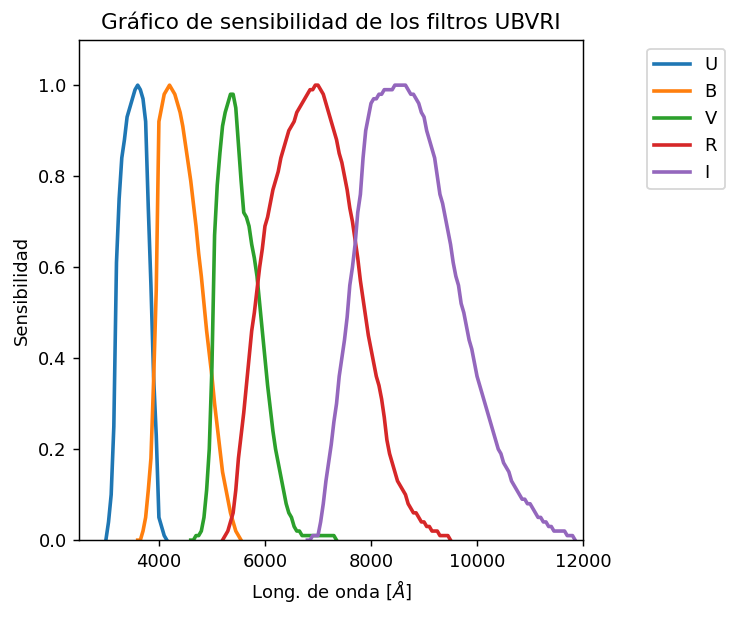

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 5), dpi = 130 )

ax.plot ( 
    data[ (data['filtro']=='U') ]['long'], 
    data[ (data['filtro']=='U') ]['sen'], 
    linewidth = 2, label = "U" 
)
ax.plot ( 
    data[ (data['filtro']=='B') ]['long'], 
    data[ (data['filtro']=='B') ]['sen'], 
    linewidth = 2, label = "B" 
)
ax.plot ( 
    data[ (data['filtro']=='V') ]['long'], 
    data[ (data['filtro']=='V') ]['sen'], 
    linewidth = 2, label = "V" 
)
ax.plot ( 
    data[ (data['filtro']=='R') ]['long'], 
    data[ (data['filtro']=='R') ]['sen'], 
    linewidth = 2, label = "R" 
)
ax.plot ( 
    data[ (data['filtro']=='I') ]['long'], 
    data[ (data['filtro']=='I') ]['sen'], 
    linewidth = 2, label = "I" 
)

ax.set_xlabel ( 'Long. de onda [$\AA$]' )
ax.set_ylabel ( 'Sensibilidad' )

ax.set_xlim(2500, 12000)
ax.set_ylim(0, 1.1)

ax.set_title('Gráfico de sensibilidad de los filtros UBVRI')

plt.legend ( bbox_to_anchor = (1.3,1), ncol = 1 )
plt.show()

¿Cómo filtrar el archivo de entrada en bandas (U, B, V)?

In [4]:
dataU = data[ data['filtro'] == 'U' ] 
dataU

,filtro,long,sen,sen_nor
229,U,3000,0.00,0.00
230,U,3050,0.04,0.04
231,U,3100,0.10,0.10
232,U,3150,0.25,0.25
233,U,3200,0.61,0.61
234,U,3250,0.75,0.75
235,U,3300,0.84,0.84
236,U,3350,0.88,0.88
237,U,3400,0.93,0.93
238,U,3450,0.95,0.95


In [5]:
dataV = data[ data['filtro'] == 'V' ] 
dataB = data[ data['filtro'] == 'B' ] 

Descargo el archivo de sensibilidades de la página de GEMINI:

In [6]:
gmos_g = pd.read_csv ( '../data/gmos_s_g_G0325_jun2017.txt', 
                     sep =r"\s+", comment = '#', header = None )
#Descargue el rchivo y lo agregué a la carpeta data porque no me dejaba abrirlo desde la pagina, luego cambie la sep=' ' por sep=r"\s+" porque el archivo tiene varias espacios entre cada columna
gmos_r = pd.read_csv ( '../data/gmos_s_r_G0326_jun2017.txt', 
                     sep =r"\s+", comment = '#', header = None )
gmos_i = pd.read_csv ( '../data/gmos_s_i_G0327_jun2017.txt', 
                     sep =r"\s+", comment = '#', header = None )
gmos_u = pd.read_csv ( '../data/gmos_s_u_G0332_jun2017.txt', 
                     sep =r"\s+", comment = '#', header = None )
#Hice lo mismo para todos los otros archivos

In [7]:
#PRUEBAS
import os

ruta = '../data/gmos_s_u_G0332_jun2017.txt'
print("Existe:", os.path.exists(ruta))
print("Tamaño:", os.path.getsize(ruta))

Existe: True
Tamaño: 114358


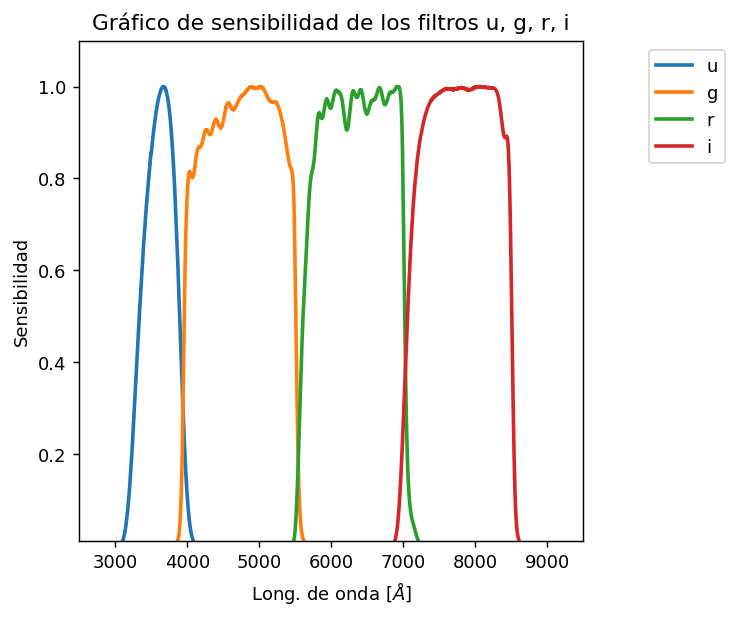

In [8]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 5), dpi = 130 )

ax.plot ( gmos_u[0] * 10., gmos_u[1]/ gmos_u[1].max(), linewidth = 2, label = "u" )
ax.plot ( gmos_g[0] * 10., gmos_g[1]/ gmos_g[1].max(), linewidth = 2, label = "g" ) # Paso la long. de onda a \AA
ax.plot ( gmos_r[0] * 10., gmos_r[1]/ gmos_r[1].max(), linewidth = 2, label = "r" ) 
ax.plot ( gmos_i[0] * 10., gmos_i[1]/ gmos_i[1].max(), linewidth = 2, label = "i" ) 


ax.set_xlabel ( 'Long. de onda [$\AA$]' )
ax.set_ylabel ( 'Sensibilidad' )

ax.set_xlim(2500, 9500)
ax.set_ylim(0.01, 1.1)

ax.set_title('Gráfico de sensibilidad de los filtros u, g, r, i')


plt.legend ( bbox_to_anchor = (1.3,1), ncol = 1 )
plt.show()

In [9]:
import pandas as pd
gmos_Ha = pd.read_csv ( '../data/gmos_s_Ha_G0336_jun2017.txt', 
                     sep =r"\s+", comment = '#', header = None )

gmos_HaC = pd.read_csv ( '../data/gmos_s_HaC_G0337_jun2017.txt', 
                     sep =r"\s+", comment = '#', header = None )

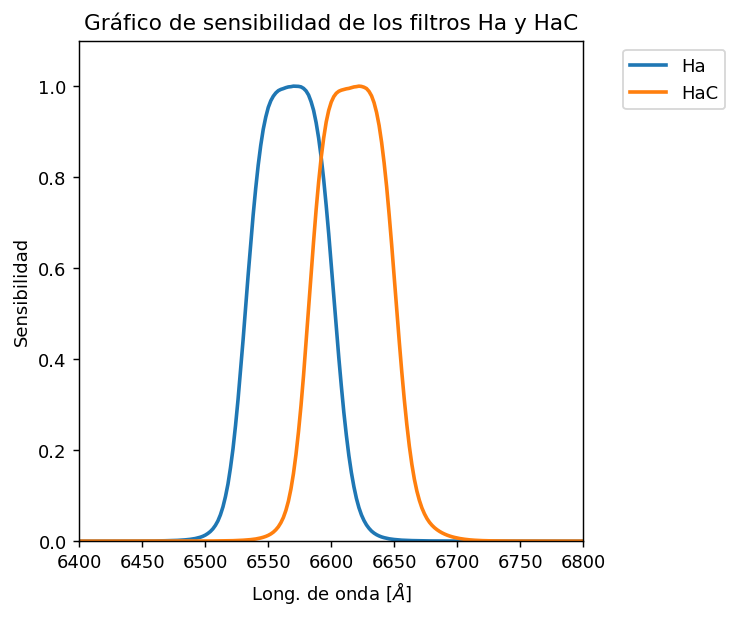

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 5), dpi = 130 )

ax.plot ( gmos_Ha[0] * 10., gmos_Ha[1]/ gmos_Ha[1].max(), linewidth = 2, label = "Ha" )
ax.plot ( gmos_HaC[0] * 10., gmos_HaC[1]/ gmos_HaC[1].max(), linewidth = 2, label = "HaC" ) # Paso la long. de onda a \AA


ax.set_xlabel ( 'Long. de onda [$\AA$]' )
ax.set_ylabel ( 'Sensibilidad' )

ax.set_xlim(6400, 6800)
ax.set_ylim(0, 1.1)

ax.set_title('Gráfico de sensibilidad de los filtros Ha y HaC')

plt.legend ( bbox_to_anchor = (1.3,1), ncol = 1 )
plt.show()

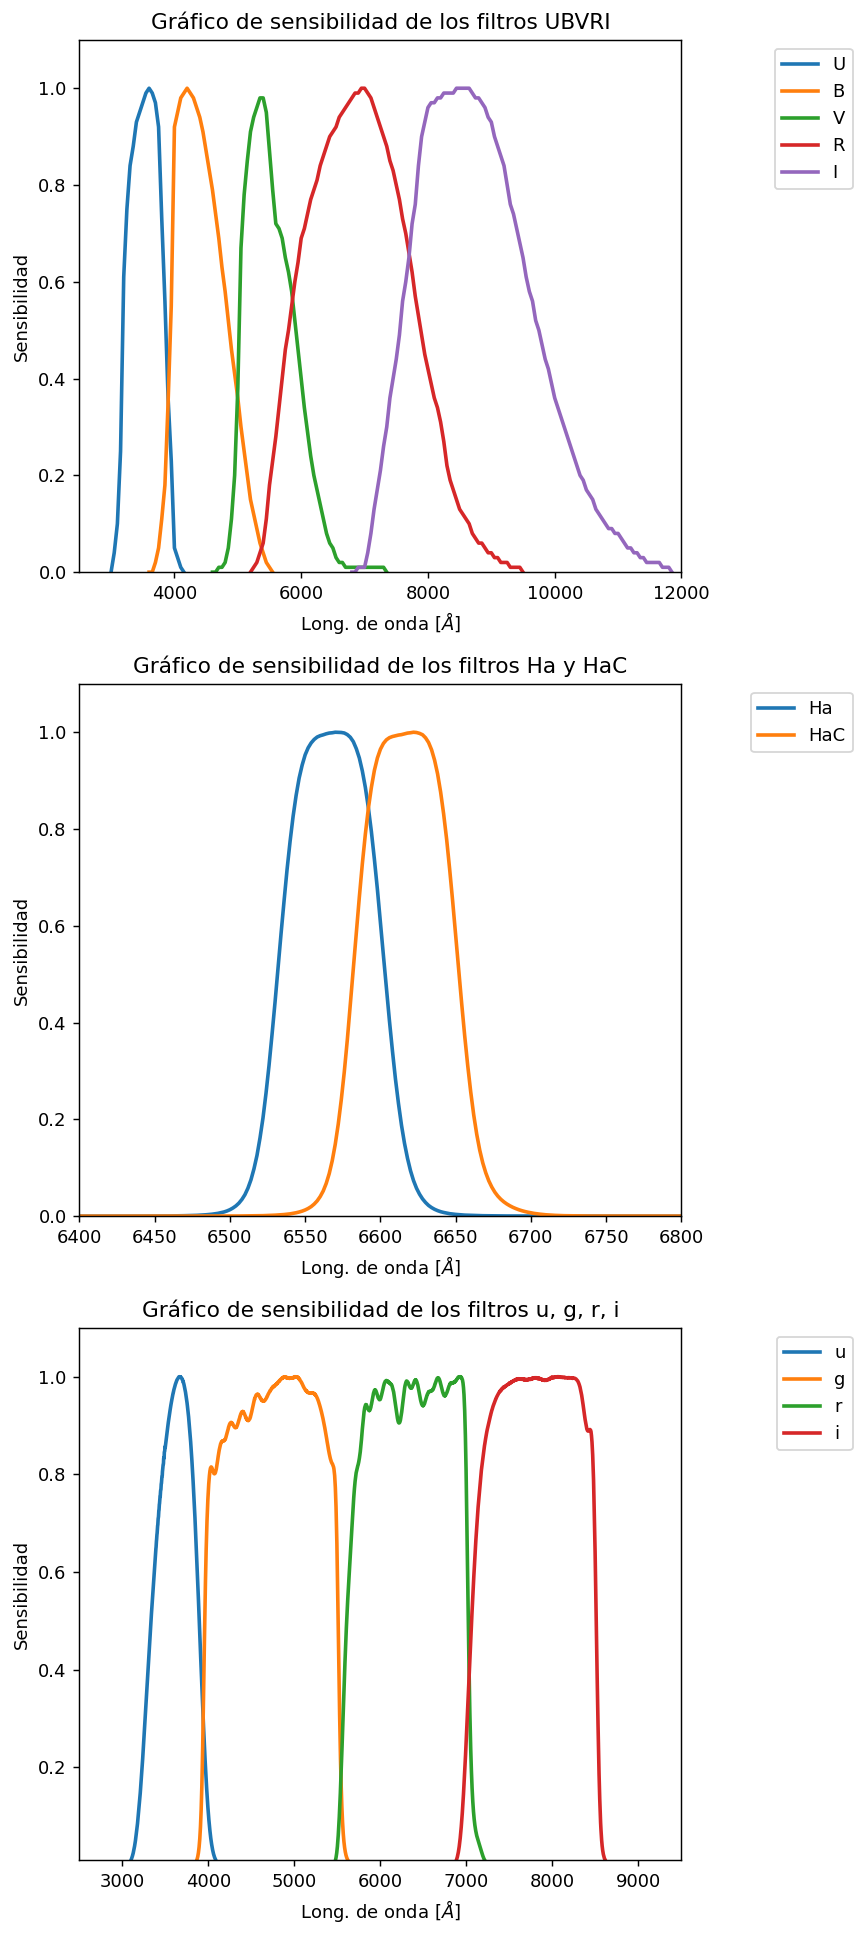

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows = 3, ncols = 1, figsize = (7, 15), dpi = 130)

# =========================
# PRIMER GRÁFICO: UBVRI
# =========================

axs[0].plot ( 
    data[ (data['filtro']=='U') ]['long'], 
    data[ (data['filtro']=='U') ]['sen'], 
    linewidth = 2, label = "U" 
)
axs[0].plot ( 
    data[ (data['filtro']=='B') ]['long'], 
    data[ (data['filtro']=='B') ]['sen'], 
    linewidth = 2, label = "B" 
)
axs[0].plot ( 
    data[ (data['filtro']=='V') ]['long'], 
    data[ (data['filtro']=='V') ]['sen'], 
    linewidth = 2, label = "V" 
)
axs[0].plot ( 
    data[ (data['filtro']=='R') ]['long'], 
    data[ (data['filtro']=='R') ]['sen'], 
    linewidth = 2, label = "R" 
)
axs[0].plot ( 
    data[ (data['filtro']=='I') ]['long'], 
    data[ (data['filtro']=='I') ]['sen'], 
    linewidth = 2, label = "I" 
)

axs[0].set_xlabel ( 'Long. de onda [$\AA$]' )
axs[0].set_ylabel ( 'Sensibilidad' )

axs[0].set_xlim(2500, 12000)
axs[0].set_ylim(0, 1.1)

axs[0].set_title('Gráfico de sensibilidad de los filtros UBVRI')

axs[0].legend ( bbox_to_anchor = (1.3,1), ncol = 1 )


# =========================
# SEGUNDO GRÁFICO: Ha y HaC
# =========================

axs[1].plot ( gmos_Ha[0] * 10., gmos_Ha[1]/ gmos_Ha[1].max(), linewidth = 2, label = "Ha" )
axs[1].plot ( gmos_HaC[0] * 10., gmos_HaC[1]/ gmos_HaC[1].max(), linewidth = 2, label = "HaC" )

axs[1].set_xlabel ( 'Long. de onda [$\AA$]' )
axs[1].set_ylabel ( 'Sensibilidad' )

axs[1].set_xlim(6400, 6800)
axs[1].set_ylim(0, 1.1)

axs[1].set_title('Gráfico de sensibilidad de los filtros Ha y HaC')

axs[1].legend ( bbox_to_anchor = (1.3,1), ncol = 1 )


# =========================
# TERCER GRÁFICO: ugr i
# =========================

axs[2].plot ( gmos_u[0] * 10., gmos_u[1]/ gmos_u[1].max(), linewidth = 2, label = "u" )
axs[2].plot ( gmos_g[0] * 10., gmos_g[1]/ gmos_g[1].max(), linewidth = 2, label = "g" )
axs[2].plot ( gmos_r[0] * 10., gmos_r[1]/ gmos_r[1].max(), linewidth = 2, label = "r" ) 
axs[2].plot ( gmos_i[0] * 10., gmos_i[1]/ gmos_i[1].max(), linewidth = 2, label = "i" ) 

axs[2].set_xlabel ( 'Long. de onda [$\AA$]' )
axs[2].set_ylabel ( 'Sensibilidad' )

axs[2].set_xlim(2500, 9500)
axs[2].set_ylim(0.01, 1.1)

axs[2].set_title('Gráfico de sensibilidad de los filtros u, g, r, i')

axs[2].legend ( bbox_to_anchor = (1.3,1), ncol = 1 )


plt.tight_layout()
plt.show()

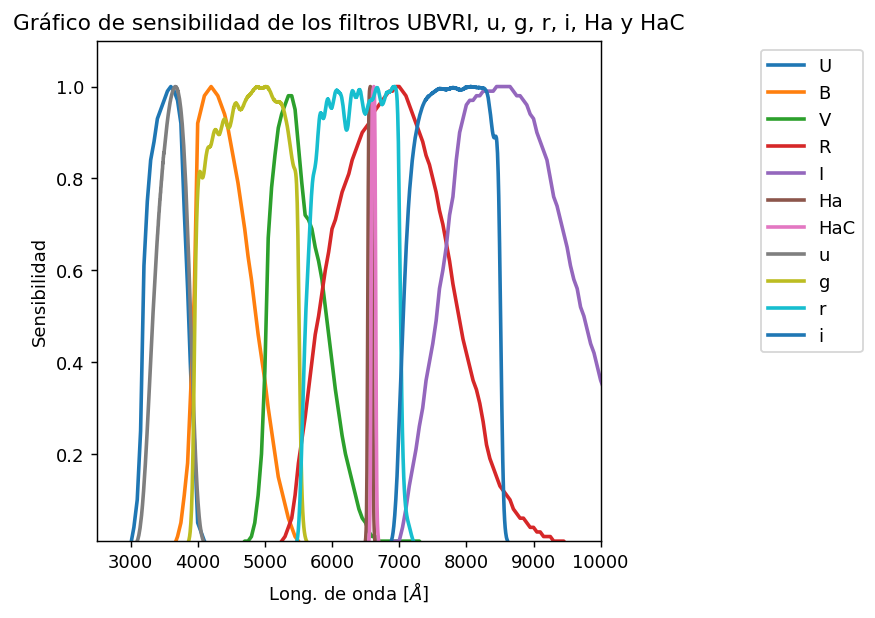

In [12]:
#Junto los tres gráficos en uno solo

import matplotlib.pyplot as plt

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 5), dpi = 130 )

#Las curvas de los filtros UBVRI
ax.plot ( 
    data[ (data['filtro']=='U') ]['long'], 
    data[ (data['filtro']=='U') ]['sen'], 
    linewidth = 2, label = "U" 
)
ax.plot ( 
    data[ (data['filtro']=='B') ]['long'], 
    data[ (data['filtro']=='B') ]['sen'], 
    linewidth = 2, label = "B" 
)
ax.plot ( 
    data[ (data['filtro']=='V') ]['long'], 
    data[ (data['filtro']=='V') ]['sen'], 
    linewidth = 2, label = "V" 
)
ax.plot ( 
    data[ (data['filtro']=='R') ]['long'], 
    data[ (data['filtro']=='R') ]['sen'], 
    linewidth = 2, label = "R" 
)
ax.plot ( 
    data[ (data['filtro']=='I') ]['long'], 
    data[ (data['filtro']=='I') ]['sen'], 
    linewidth = 2, label = "I" 
)

#Las curvas de los filtros Ha y HaC
ax.plot ( gmos_Ha[0] * 10., gmos_Ha[1]/ gmos_Ha[1].max(), linewidth = 2, label = "Ha" )
ax.plot ( gmos_HaC[0] * 10., gmos_HaC[1]/ gmos_HaC[1].max(), linewidth = 2, label = "HaC" ) # Paso la long. de onda a \AA

#Las curvas de los filtros u, g, r, i
ax.plot ( gmos_u[0] * 10., gmos_u[1]/ gmos_u[1].max(), linewidth = 2, label = "u" )
ax.plot ( gmos_g[0] * 10., gmos_g[1]/ gmos_g[1].max(), linewidth = 2, label = "g" ) # Paso la long. de onda a \AA
ax.plot ( gmos_r[0] * 10., gmos_r[1]/ gmos_r[1].max(), linewidth = 2, label = "r" ) 
ax.plot ( gmos_i[0] * 10., gmos_i[1]/ gmos_i[1].max(), linewidth = 2, label = "i" ) 


ax.set_xlabel ( 'Long. de onda [$\AA$]' )
ax.set_ylabel ( 'Sensibilidad' )

ax.set_xlim(2500, 10000)
ax.set_ylim(0.01, 1.1)

ax.set_title('Gráfico de sensibilidad de los filtros UBVRI, u, g, r, i, Ha y HaC')

plt.legend ( bbox_to_anchor = (1.3,1), ncol = 1 )
plt.show()

**2.** Calcular la longitud de onda equivalente y efectiva

Sin considerar la radiación proveniente de la fuente, se puede definir
la longitud de onda media o equivalente $\lambda_{0}$ de un filtro,
de la siguiente forma:

\begin{equation}
  \lambda_{0} = \frac{\int \lambda ~ S(\lambda) ~ d\lambda }{\int S(\lambda) ~ d\lambda}
\end{equation}

en donde $S(\lambda)$ representa la función de transmición del
filtro. Si, por lo contrario, se tiene en cuenta la distribución de
energía de la fuente, se puede definir la longitud de onda efectiva
$\lambda_{e}$:

\begin{equation}
  \lambda_{e} = \frac{\int \lambda ~ S(\lambda) ~ F(\lambda) ~ d\lambda }{\int S(\lambda) ~ F(\lambda) ~ d\lambda} 
\end{equation}

en donde $F(\lambda)$ es la distribución de energía de la fuente.

Para hacer lo anterior, utilizaremos el método de integración para datos provenientes de un archivo de texto:

En este caso vamos a mostrar cómo integrar mediante el [método de Simpson](https://es.wikipedia.org/wiki/Regla_de_Simpson) (```simp``` de ```scipy```) y vamos a usar el módelo de cuerpo negro (```BlackBody``` de ```astropy```).
El método de Simpson utiliza subintervalos de la dada función $f(x)$ aproximando por un polinomio de primer grado $P(x)$:

\begin{equation}
\int_a^b f(x)\ dx \equiv \frac{\Delta x}{3} \sum_{i = 1}^{N/2} \left[f(x_{2i-2}) + 4 f(x_{2i-1}) + f(x_{2i}) \right]
\end{equation}

dónde $\Delta x = (b-a)/N$, $x_{i} = a + i \Delta x$.

Manual de ```simp```: https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.integrate.simps.html

In [13]:
from astropy.modeling.models import BlackBody
from astropy import units as u

bb = BlackBody ( temperature = 6000 * u.K )
print(bb(4000 * u.AA))

1.5504456087808982e-05 erg / (Hz s sr cm2)


In [14]:
dataU = data[ data['filtro'] == 'U' ] 
dataV = data[ data['filtro'] == 'V' ] 
dataB = data[ data['filtro'] == 'B' ] 

In [15]:
from scipy.integrate import simpson # Cmabie simps por simpson porque me daba error, no se si es por la versión de scipy que tengo instalada
import numpy as np

LOM_numerador = simpson( dataU['long'] * dataU['sen'], x = dataU['long'] ) # Borrar el argumento
LOM_denominador = simpson( dataU['sen'], x = dataU['long'] )

print ( "[*] Long. de onda equivalente filtro U[$\AA$] = ", LOM_numerador/LOM_denominador )

LOM_numerador = simpson( dataB['long'] * dataB['sen'], x = dataB['long'] ) # Borrar el argumento
LOM_denominador = simpson( dataB['sen'], x = dataB['long'] )

print ( "[*] Long. de onda equivalente filtro B[$\AA$] = ", LOM_numerador/LOM_denominador )


LOM_numerador = simpson( dataV['long'] * dataV['sen'], x = dataV['long'] ) # Borrar el argumento
LOM_denominador = simpson( dataV['sen'], x = dataV['long'] )

print ( "[*] Long. de onda equivalente filtro V[$\AA$] = ", LOM_numerador/LOM_denominador )



# Para la integral por Simpson, _python_u tiene:
# integral = simps( integrando['X'], x = X ) 

[*] Long. de onda equivalente filtro U[$\AA$] =  3537.8678564647807
[*] Long. de onda equivalente filtro B[$\AA$] =  4440.611526616806
[*] Long. de onda equivalente filtro V[$\AA$] =  5535.53009270152


In [16]:
# Faltaría calcular la long de onda efectiva.
from scipy.integrate import simpson
from astropy.modeling.models import BlackBody
from astropy import units as u
import numpy as np

bb = BlackBody (temperature=6000 * u.K)
dataU['flux'] = [bb(lon * u.AA).value for lon in dataU['long']]

LOM_numerador = simpson( dataU['long'] * dataU['sen'] * dataU['flux'], x = dataU['long'] ) # Borrar el argumento
LOM_denominador = simpson( dataU['sen'] * dataU['flux'], x = dataU['long'] )

print ( "[*] Long. de onda efectva filtro U[$\AA$] = ", LOM_numerador/LOM_denominador )


dataB['flux'] = [bb(lon * u.AA).value for lon in dataB['long']]

LOM_numerador = simpson( dataB['long'] * dataB['sen'] * dataB['flux'], x = dataB['long'] ) # Borrar el argumento
LOM_denominador = simpson( dataB['sen'] * dataB['flux'], x = dataB['long'] )

print ( "[*] Long. de onda efectva filtro B[$\AA$] = ", LOM_numerador/LOM_denominador )


dataV['flux'] = [bb(lon * u.AA).value for lon in dataV['long']]

LOM_numerador = simpson( dataV['long'] * dataV['sen'] * dataV['flux'], x = dataV['long'] ) # Borrar el argumento
LOM_denominador = simpson( dataV['sen'] * dataV['flux'], x = dataV['long'] )

print ( "[*] Long. de onda efectva filtro V[$\AA$] = ", LOM_numerador/LOM_denominador )

[*] Long. de onda efectva filtro U[$\AA$] =  3585.9653885932667
[*] Long. de onda efectva filtro B[$\AA$] =  4506.285096255145
[*] Long. de onda efectva filtro V[$\AA$] =  5569.04426403717


**3.** Vamos a unir los archivos de la distribución de energia $F(\lambda)$ y la sensibilidad $S(\lambda)$ del filtro para calcular el índice de color


\begin{equation}
  m_{V} = C_{0V} - 2.5\ log\left(\int F(\lambda)\ S(\lambda)\ d\lambda\right)
\end{equation}

dónde $C_{0V}$ es el punto de cero del filtro. Luego, calculando lo mismo para el filtro B, se puede obtener el índice de color 

\begin{equation}
  (b-v) = m_{B} - m_{v}
\end{equation}

In [17]:
import pandas as pd
# Primer parte
# Defino una matriz con los puntos de cero de cada filtro
C = pd.DataFrame ( {"C0": [21.100, 21.750, 20.830]}, index = ['V', 'B', 'U'] )  
print (C)

      C0
V  21.10
B  21.75
U  20.83


In [18]:
print ( C.loc['V','C0'] )

21.1


In [19]:
# Segunda parte
distribucion = pd.read_csv("../data/distribucion_espectral_K5V.dat", names = ['long2', 'int'], #Modifique la ruta porque no me figuraba el archivo 
                           sep = " ", comment = '#', header = None)
distribucion['long2'] = distribucion['long2'] * 10. # Para convertir la long. de onda de nm a AA.
print ( distribucion )

       long2   int
0     1200.0   0.0
1     1250.0   0.0
2     1300.0   0.0
3     1350.0   0.0
4     1400.0   0.0
..       ...   ...
183  10350.0  80.5
184  10400.0  81.2
185  10450.0  80.0
186  10500.0  78.5
187  12500.0  54.0

[188 rows x 2 columns]


In [20]:
# Tercer parte

#  Filtro la distribución de la fuente según la long. de onda
#   disponible en el archivo de sensibilidades.

min = dataV['long'].min() # Calculo el minimo y máximo
max = dataV['long'].max() #  de las long. de onda.
print ( "[*] min y máx de la long. de onda (V) = ", min, max )

#Hago lo mismo para B y U

min_B = dataB['long'].min()
max_B = dataB['long'].max()
print ( "[*] min y máx de la long. de onda (B) = ", min_B, max_B )

min_U = dataU['long'].min()
max_U = dataU['long'].max()
print ( "[*] min y máx de la long. de onda (U) = ", min_U, max_U )


[*] min y máx de la long. de onda (V) =  4600 7350
[*] min y máx de la long. de onda (B) =  3600 5550
[*] min y máx de la long. de onda (U) =  3000 4150


In [21]:
dist_filtrada_V = distribucion[ (distribucion['long2'] >= min) & (distribucion['long2'] <= max) ] # Filtro por banda.
##      Notar: el espaciado en de la sensibilidad y de la distribucion es la misma (50 AA),
##             por lo que no hay que hacer ninguna interpolación.
print ( dist_filtrada_V )

# Lo mismo para B y U

dist_filtrada_B = distribucion[(distribucion['long2'] >= min_B) & (distribucion['long2'] <= max_B)]
print ( dist_filtrada_B )

dist_filtrada_U = distribucion[(distribucion['long2'] >= min_U) & (distribucion['long2'] <= max_U)]
print ( dist_filtrada_U )

      long2    int
68   4600.0   81.0
69   4650.0   82.0
70   4700.0   82.2
71   4750.0   79.0
72   4800.0   76.0
73   4850.0   79.5
74   4900.0   79.5
75   4950.0   78.0
76   5000.0   72.0
77   5050.0   66.5
78   5100.0   62.0
79   5150.0   60.5
80   5200.0   61.8
81   5250.0   77.0
82   5300.0   88.0
83   5350.0   92.0
84   5400.0   93.5
85   5450.0   96.5
86   5500.0  100.0
87   5550.0  104.0
88   5600.0  101.5
89   5650.0  108.0
90   5700.0  109.5
91   5750.0  112.0
92   5800.0  113.0
93   5850.0  112.0
94   5900.0  100.0
95   5950.0  116.0
96   6000.0  114.5
97   6050.0  117.5
98   6100.0  113.0
99   6150.0  109.5
100  6200.0  111.5
101  6250.0  109.0
102  6300.0  112.0
103  6350.0  114.0
104  6400.0  113.0
105  6450.0  114.0
106  6500.0  117.5
107  6550.0  120.0
108  6600.0  119.5
109  6650.0  118.0
110  6700.0  115.5
111  6750.0  113.5
112  6800.0  111.5
113  6850.0  109.5
114  6900.0  110.0
115  6950.0  112.5
116  7000.0  114.5
117  7050.0  115.0
118  7100.0  114.5
119  7150.0 

In [22]:
# Noten que ambas matrices tienen el mismo tamaño
print ( len(dist_filtrada_V), len(dataV) )
print ( len(dist_filtrada_B), len(dataB) )
print ( len(dist_filtrada_U), len(dataU) )

56 56
40 40
24 24


In [23]:
# Cuarta parte
dataV = dataV.reset_index ( drop = True ) # Vuelve a cero los indices.
dist_filtrada_V = dist_filtrada_V.reset_index ( drop = True )

# como tienen el mismo tamaño, lo puedo pegar:
output = dist_filtrada_V.join(dataV)
print(output)

#Lo mismo para B y U

dataB = dataB.reset_index ( drop = True ) # Vuelve a cero los indices.
dist_filtrada_B = dist_filtrada_B.reset_index ( drop = True )

output_B = dist_filtrada_B.join(dataB)
print(output_B)

dataU = dataU.reset_index ( drop = True ) # Vuelve a cero los indices.
dist_filtrada_U = dist_filtrada_U.reset_index ( drop = True )

output_U = dist_filtrada_U.join(dataU)
print(output_U)


     long2    int filtro  long   sen  sen_nor      flux
0   4600.0   81.0      V  4600  0.00    0.000  0.000022
1   4650.0   82.0      V  4650  0.00    0.000  0.000023
2   4700.0   82.2      V  4700  0.01    0.010  0.000023
3   4750.0   79.0      V  4750  0.01    0.010  0.000024
4   4800.0   76.0      V  4800  0.02    0.020  0.000024
5   4850.0   79.5      V  4850  0.05    0.051  0.000025
6   4900.0   79.5      V  4900  0.11    0.112  0.000025
7   4950.0   78.0      V  4950  0.20    0.204  0.000026
8   5000.0   72.0      V  5000  0.38    0.388  0.000026
9   5050.0   66.5      V  5050  0.67    0.684  0.000027
10  5100.0   62.0      V  5100  0.78    0.796  0.000027
11  5150.0   60.5      V  5150  0.85    0.867  0.000028
12  5200.0   61.8      V  5200  0.91    0.929  0.000028
13  5250.0   77.0      V  5250  0.94    0.959  0.000029
14  5300.0   88.0      V  5300  0.96    0.980  0.000029
15  5350.0   92.0      V  5350  0.98    1.000  0.000030
16  5400.0   93.5      V  5400  0.98    1.000  0

In [24]:
from scipy.integrate import simpson 
# Quinta parte
V = C.loc['V','C0'] - 2.5 * np.log10 ( simpson(output['int']*output['sen'], x = output['long']) ) #Cambié simpspor simpson
print ("[*]  V = ", V)

B = C.loc['B','C0'] - 2.5 * np.log10 ( simpson(output_B['int']*output_B['sen'], x = output_B['long']) )
print ("[*]  B = ", B)

U = C.loc['U','C0'] - 2.5 * np.log10 ( simpson(output_U['int']*output_U['sen'], x = output_U['long']) )
print ("[*]  U = ", U)


[*]  V =  8.800712760638728
[*]  B =  9.961328928845269
[*]  U =  11.117296966449945


In [25]:
# Falta calculo en los filtros U, y B
#Lo hice en cada uno de los pasos anteriores

In [26]:
print ("[*] color instrumental (b-v) = ", B-V)

[*] color instrumental (b-v) =  1.1606161682065412


In [27]:
print ("[*] color instrumental (u-b) = ", U-B)

[*] color instrumental (u-b) =  1.1559680376046764


**3.** Diagrama color-color

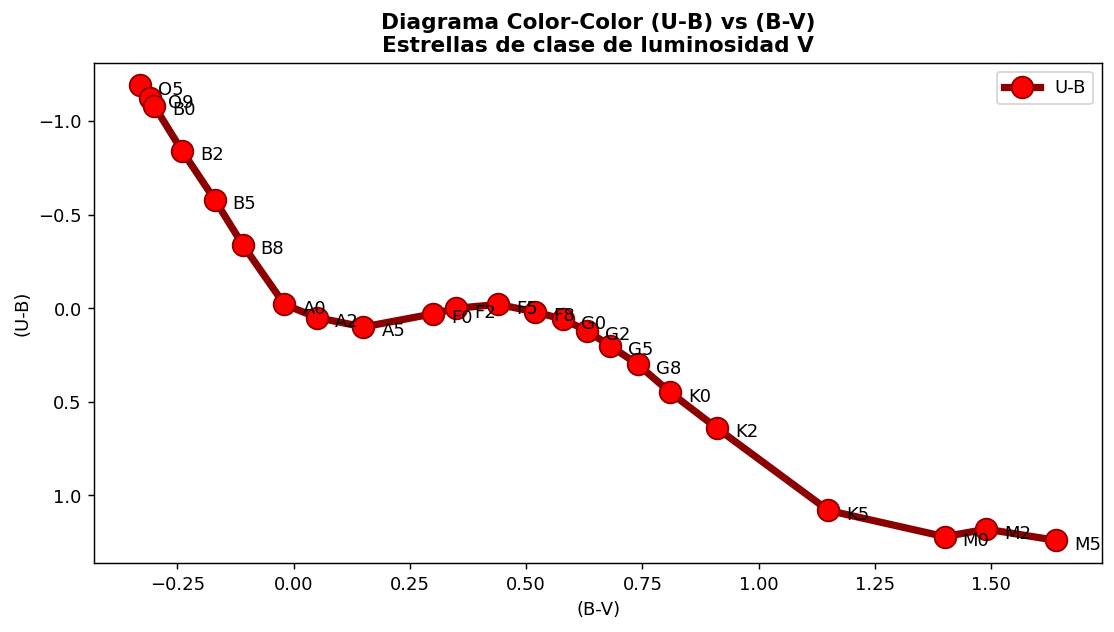

In [28]:
import matplotlib.pyplot as plt

diagrama = pd.read_csv ( '../data/V.dat', sep = " ", comment = '#' ) # Cambié la ruta porque no me figuraba el archivo

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (10,5), dpi = 130 )
ax.plot( 'B-V', 'U-B', data = diagrama, marker = 'o', 
         markerfacecolor = 'red', markersize = 12, color = 'darkred', linewidth = 4 )

# Agrega el tipo espectral
for i in diagrama.index:
    plt.annotate ( diagrama.loc[i]['Sp'], xy = ( diagrama.loc[i]['B-V'], diagrama.loc[i]['U-B'] ),
                xytext = (10, -5), textcoords = 'offset points',
                family = 'sans-serif', fontsize = 10, color = 'black' )
        
ax.set_xlabel('(B-V)')
ax.set_ylabel('(U-B)')
plt.gca().invert_yaxis()

ax.set_title('Diagrama Color-Color (U-B) vs (B-V)\nEstrellas de clase de luminosidad V', fontweight='bold')
ax.legend()
plt.show()



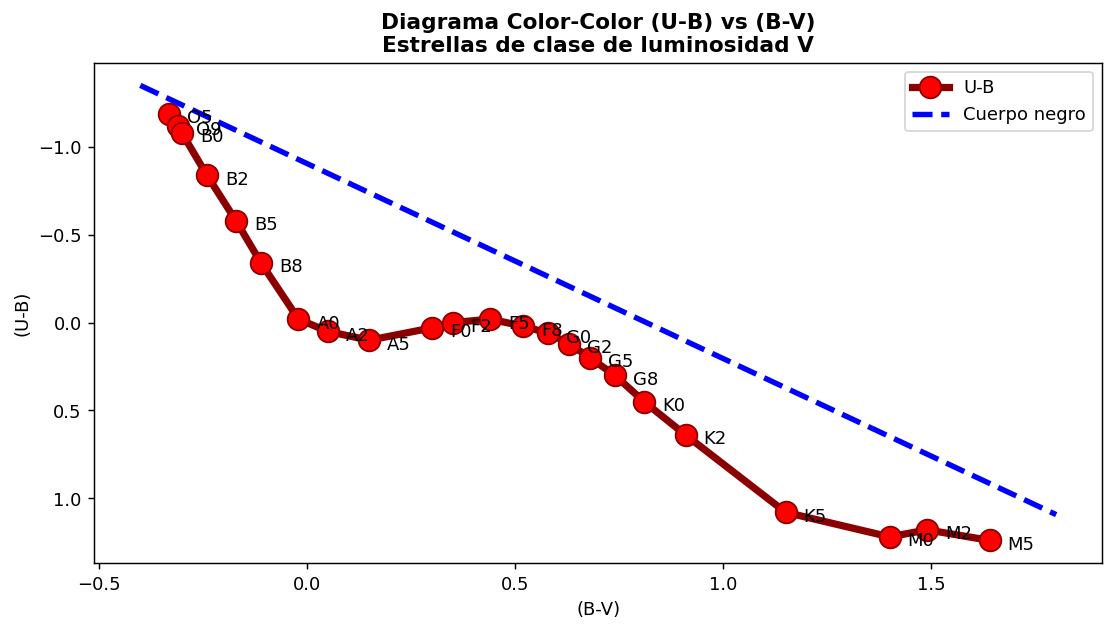

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

diagrama = pd.read_csv ( '../data/V.dat', sep = " ", comment = '#' )

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (10,5), dpi = 130 )

ax.plot( 'B-V', 'U-B', data = diagrama, marker = 'o',
         markerfacecolor = 'red', markersize = 12,
         color = 'darkred', linewidth = 4 )

# Agrega el tipo espectral
for i in diagrama.index:
    plt.annotate ( diagrama.loc[i]['Sp'],
                xy = ( diagrama.loc[i]['B-V'], diagrama.loc[i]['U-B'] ),
                xytext = (10, -5),
                textcoords = 'offset points',
                family = 'sans-serif',
                fontsize = 10,
                color = 'black' )



A = -0.57
C = -1.54

Bbv = 7101
Bub = 7890

x = np.linspace(-0.4, 1.8, 500)

y = (Bub/Bbv) * x - (Bub*A/Bbv) + C

ax.plot(x, y,
        color = 'blue',
        linewidth = 3,
        linestyle = '--',
        label = 'Cuerpo negro')



ax.set_xlabel('(B-V)')
ax.set_ylabel('(U-B)')

plt.gca().invert_yaxis()

ax.set_title('Diagrama Color-Color (U-B) vs (B-V)\nEstrellas de clase de luminosidad V',
             fontweight='bold')

ax.legend()

plt.show()

**4.** Descargo la distribución espectral de una estrella tipo A0 de Vizier (en formato pandas) y convoluciono con la sensibilidad del filtro V (que ya teniamos cargado).

In [30]:
A0 = pd.read_csv("http://cdsarc.u-strasbg.fr/viz-bin/nph-Plot/Vgraph/txt?VI%2f50&I%28A0V%29", 
                 names = ['l','I'], sep = "\t", comment = '#', header = None)
A0['l'] = A0['l'] * 10. # Para convertir la long. de onda de nm a AA.

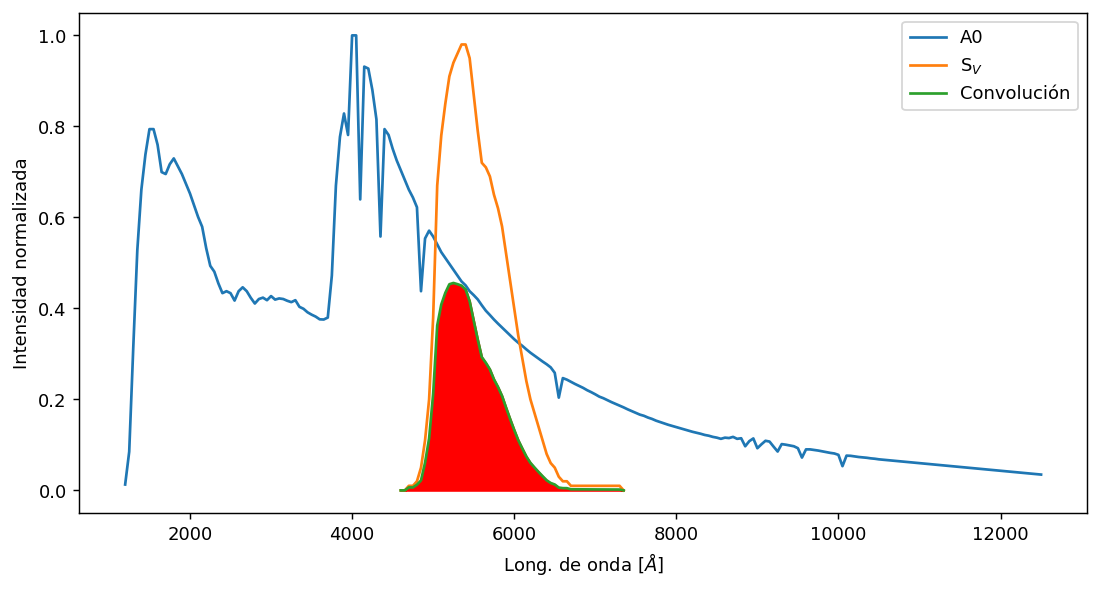

In [31]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (10, 5), dpi = 130 )
ax.plot ( A0['l'], A0['I']/A0['I'].max() ) # Normalizo con el máximo de la distribución
ax.plot ( dataV['long'], dataV['sen'] )

## Filtro la distribución, teniendo en cuenta el máx y mín del archivo de sensibilidades
A0_filtrada =  A0[(A0['l'] >= dataV['long'].min()) & (A0['l'] <= dataV['long'].max())] # Filtro por banda

dataV = dataV.reset_index(drop=True) # Vuelve a cero los indices.
A0_filtrada = A0_filtrada.reset_index(drop=True)

output = A0_filtrada.join(dataV) # Junto las matrices
#print (output)
##

ax.plot ( output['long'], output['I']*output['sen']/A0['I'].max() )

ax.fill_between( output['long'], 0, output['I']*output['sen']/A0['I'].max(), 
                 color = "red", interpolate = True )

plt.legend(labels = ['A0','S$_{V}$', 'Convolución'] )

plt.xlabel('Long. de onda [$\AA$]')
plt.ylabel('Intensidad normalizada')

plt.show()